# Baseline Model Comparison: GPR vs. Linear Regression vs. Random Forest

This notebook compares the BayBE GPR surrogate model (botorch `SingleTaskGP`) against two simpler baselines — **Linear Regression** and **Random Forest** — to contextualize the GPR modeling choice.

## Motivation

The GPR was not selected as the "best regression model" through a model selection exercise. It is the surrogate model built into BayBE's Bayesian optimization loop — the posterior uncertainty of the GPR is what drives the active learning exploration strategy. Nevertheless, comparing its predictive accuracy against simpler baselines demonstrates whether the data contains nonlinear structure that justifies the GPR's complexity.

## Method

All three models are evaluated using identical 5-fold cross-validation splits on each of the 6 individual campaign datasets. Metrics reported: R² (test), RMSE, MAE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import torch
import baybe
import InitializeCampaign as ic

## Load Datasets

Same data loading as the GPR Cross-Validation notebook.

In [2]:
base_dir = Path.cwd()
HEAD_PATH = base_dir / "Bipolar Datasets - Al and Ti - low and high PW" / "Datasets Used for Publication"

dataset_registry = {
    'Al - 120 W  - short PW': 'df_campaign_Al_shortPW.json',
    'Al - 200 W - high PW': 'df_campaign_Al_highPW.json',
    'Al - 250 W - duty cycle series': 'df_campaign_Al_lowDuty.json',
    'Ti - 120 W - short PW': 'df_campaign_Ti_lowPW.json',
    'Ti - 200 W - high PW': 'df_campaign_Ti_highPW.json',
    'Ti 250 W low duty cycle': 'df_campaign_Ti_lowDuty.json',
}

PARAMS = ['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

def load_dataset(name, df_file):
    df = pd.read_json(HEAD_PATH / name / df_file)
    if 'PRR (Hz)' not in df.columns:
        df['PRR (Hz)'] = df['Duty Cycle (ratio)'] / (df['PW (us)'] * 1E-6)
    return df[PARAMS + ['y1']].copy()

datasets = {}
for name, df_file in dataset_registry.items():
    datasets[name] = load_dataset(name, df_file)
    print(f"{name}: {len(datasets[name])} samples")

Al - 120 W  - short PW: 601 samples
Al - 200 W - high PW: 651 samples
Al - 250 W - duty cycle series: 401 samples
Ti - 120 W - short PW: 495 samples
Ti - 200 W - high PW: 601 samples
Ti 250 W low duty cycle: 401 samples


## Cross-Validation Functions

In [3]:
def cv_sklearn_model(model_cls, model_kwargs, X, y, n_splits=5, scale=True):
    """K-fold CV for any sklearn regressor. Returns dict of metrics + pooled predictions."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_true_all, y_pred_all = [], []
    fold_metrics = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        model = model_cls(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        fold_metrics.append({
            'R2': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
        })
    
    return {
        'y_true_all': np.array(y_true_all),
        'y_pred_all': np.array(y_pred_all),
        'R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'R2_std': np.std([m['R2'] for m in fold_metrics]),
        'RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'MAE_std': np.std([m['MAE'] for m in fold_metrics]),
    }


def cv_baybe_gpr(campaign, df_clean, n_splits=5):
    """K-fold CV for BayBE GPR surrogate. Returns dict of metrics + pooled predictions."""
    params = [p.name for p in campaign.parameters]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_true_all, y_pred_all = [], []
    fold_metrics = []
    
    for train_idx, test_idx in kf.split(df_clean):
        df_train = df_clean.iloc[train_idx].reset_index(drop=True)
        df_test = df_clean.iloc[test_idx].reset_index(drop=True)
        
        model = campaign.get_surrogate()
        model.fit(campaign.searchspace, campaign.objective, df_train)
        
        with torch.no_grad():
            y_pred = model.posterior(df_test[params]).mean.detach().numpy().flatten()
        y_true = df_test['y1'].values
        
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)
        fold_metrics.append({
            'R2': r2_score(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
        })
    
    return {
        'y_true_all': np.array(y_true_all),
        'y_pred_all': np.array(y_pred_all),
        'R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'R2_std': np.std([m['R2'] for m in fold_metrics]),
        'RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'MAE_std': np.std([m['MAE'] for m in fold_metrics]),
    }

## Run All Models on All Datasets

In [4]:
all_results = {}  # {dataset_name: {model_name: result_dict}}

for name, df_file in dataset_registry.items():
    df_clean = datasets[name]
    X = df_clean[PARAMS].values
    y = df_clean['y1'].values
    
    print(f"\n{'='*60}")
    print(f"{name} ({len(df_clean)} samples)")
    
    # --- Linear Regression ---
    lr_result = cv_sklearn_model(LinearRegression, {}, X, y)
    print(f"  Linear Regression:  R² = {lr_result['R2_mean']:.4f} ± {lr_result['R2_std']:.4f}")
    
    # --- Random Forest ---
    rf_result = cv_sklearn_model(
        RandomForestRegressor,
        {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1},
        X, y, scale=False  # RF doesn't need scaling
    )
    print(f"  Random Forest:      R² = {rf_result['R2_mean']:.4f} ± {rf_result['R2_std']:.4f}")
    
    # --- BayBE GPR ---
    lb = [df_clean[p].min() for p in PARAMS]
    ub = [df_clean[p].max() for p in PARAMS]
    campaign = ic.init_campaign(lb, ub, PARAMS)
    campaign.add_measurements(df_clean)
    gpr_result = cv_baybe_gpr(campaign, df_clean)
    print(f"  BayBE GPR:          R² = {gpr_result['R2_mean']:.4f} ± {gpr_result['R2_std']:.4f}")
    
    all_results[name] = {
        'Linear Regression': lr_result,
        'Random Forest': rf_result,
        'BayBE GPR': gpr_result,
    }


Al - 120 W  - short PW (601 samples)
  Linear Regression:  R² = 0.2441 ± 0.0988
  Random Forest:      R² = 0.8191 ± 0.0404


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


  BayBE GPR:          R² = 0.8214 ± 0.0393

Al - 200 W - high PW (651 samples)
  Linear Regression:  R² = 0.8443 ± 0.1495
  Random Forest:      R² = 0.8270 ± 0.1430


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


  BayBE GPR:          R² = 0.7887 ± 0.1484

Al - 250 W - duty cycle series (401 samples)
  Linear Regression:  R² = 0.3588 ± 0.0581
  Random Forest:      R² = 0.6466 ± 0.0779


...

  BayBE GPR:          R² = 0.7402 ± 0.0634

Ti - 200 W - high PW (601 samples)
  Linear Regression:  R² = 0.5814 ± 0.0534
  Random Forest:      R² = 0.5914 ± 0.0688


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


  BayBE GPR:          R² = 0.6106 ± 0.0582

Ti 250 W low duty cycle (401 samples)
  Linear Regression:  R² = 0.4085 ± 0.0678
  Random Forest:      R² = 0.6329 ± 0.0461


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


  BayBE GPR:          R² = 0.6480 ± 0.0482


## Summary Table

In [5]:
rows = []
for ds_name, model_results in all_results.items():
    for model_name, result in model_results.items():
        rows.append({
            'Dataset': ds_name,
            'Model': model_name,
            'Test R²': f"{result['R2_mean']:.3f} ± {result['R2_std']:.3f}",
            'RMSE': f"{result['RMSE_mean']:.4f} ± {result['RMSE_std']:.4f}",
            'MAE': f"{result['MAE_mean']:.4f} ± {result['MAE_std']:.4f}",
        })

df_comparison = pd.DataFrame(rows)
df_comparison

,Dataset,Model,Test R²,RMSE,MAE
0,Al - 120 W - short PW,Linear Regression,0.244 ± 0.099,0.2194 ± 0.0138,0.1675 ± 0.0053
1,Al - 120 W - short PW,Random Forest,0.819 ± 0.040,0.1064 ± 0.0029,0.0874 ± 0.0027
2,Al - 120 W - short PW,BayBE GPR,0.821 ± 0.039,0.1058 ± 0.0035,0.0867 ± 0.0034
3,Al - 200 W - high PW,Linear Regression,0.844 ± 0.150,0.0736 ± 0.0363,0.0467 ± 0.0059
4,Al - 200 W - high PW,Random Forest,0.827 ± 0.143,0.0790 ± 0.0354,0.0456 ± 0.0057
5,Al - 200 W - high PW,BayBE GPR,0.789 ± 0.148,0.0880 ± 0.0363,0.0494 ± 0.0070
6,Al - 250 W - duty cycle series,Linear Regression,0.359 ± 0.058,0.4359 ± 0.0561,0.3197 ± 0.0326
7,Al - 250 W - duty cycle series,Random Forest,0.647 ± 0.078,0.3196 ± 0.0334,0.2374 ± 0.0122
8,Al - 250 W - duty cycle series,BayBE GPR,0.703 ± 0.047,0.2956 ± 0.0407,0.2184 ± 0.0125
9,Ti - 120 W - short PW,Linear Regression,0.139 ± 0.082,0.1550 ± 0.0052,0.1172 ± 0.0054


## R² Comparison Bar Chart

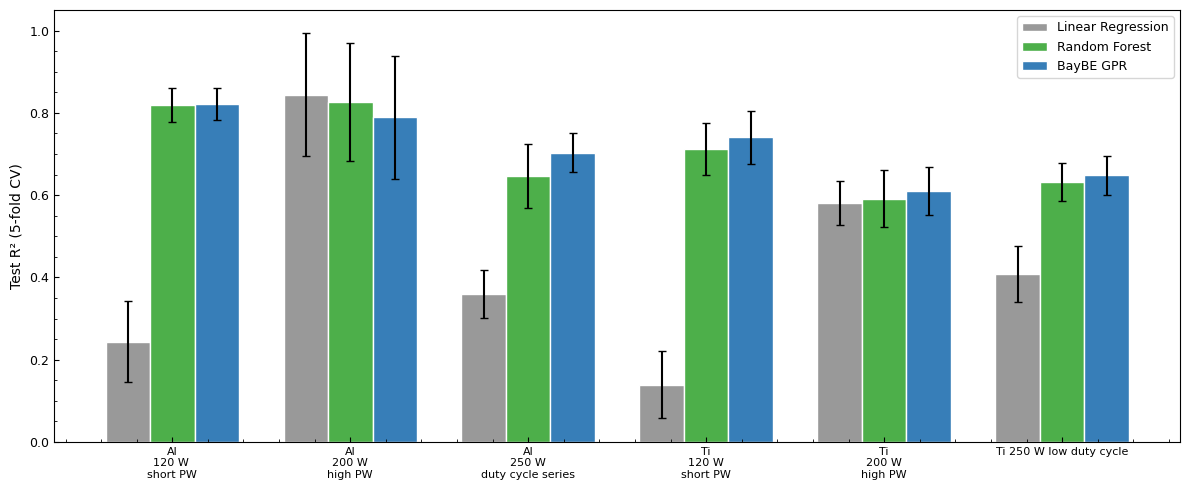

In [6]:
model_names = ['Linear Regression', 'Random Forest', 'BayBE GPR']
colors = ['#999999', '#4daf4a', '#377eb8']
ds_names = list(all_results.keys())

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(ds_names))
width = 0.25

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    means = [all_results[ds][model_name]['R2_mean'] for ds in ds_names]
    stds = [all_results[ds][model_name]['R2_std'] for ds in ds_names]
    ax.bar(x + i * width, means, width, yerr=stds, label=model_name,
           color=color, edgecolor='white', capsize=3)

ax.set_ylabel('Test R² (5-fold CV)', fontsize=10)
ax.set_xticks(x + width)
ax.set_xticklabels([n.replace(' - ', '\n') for n in ds_names], fontsize=8, ha='center')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='y', labelsize=9)
ax.minorticks_on()
ax.tick_params(which='minor', direction='in')
ax.tick_params(which='major', direction='in')

plt.tight_layout()
plt.show()

## Parity Plots (All Models)

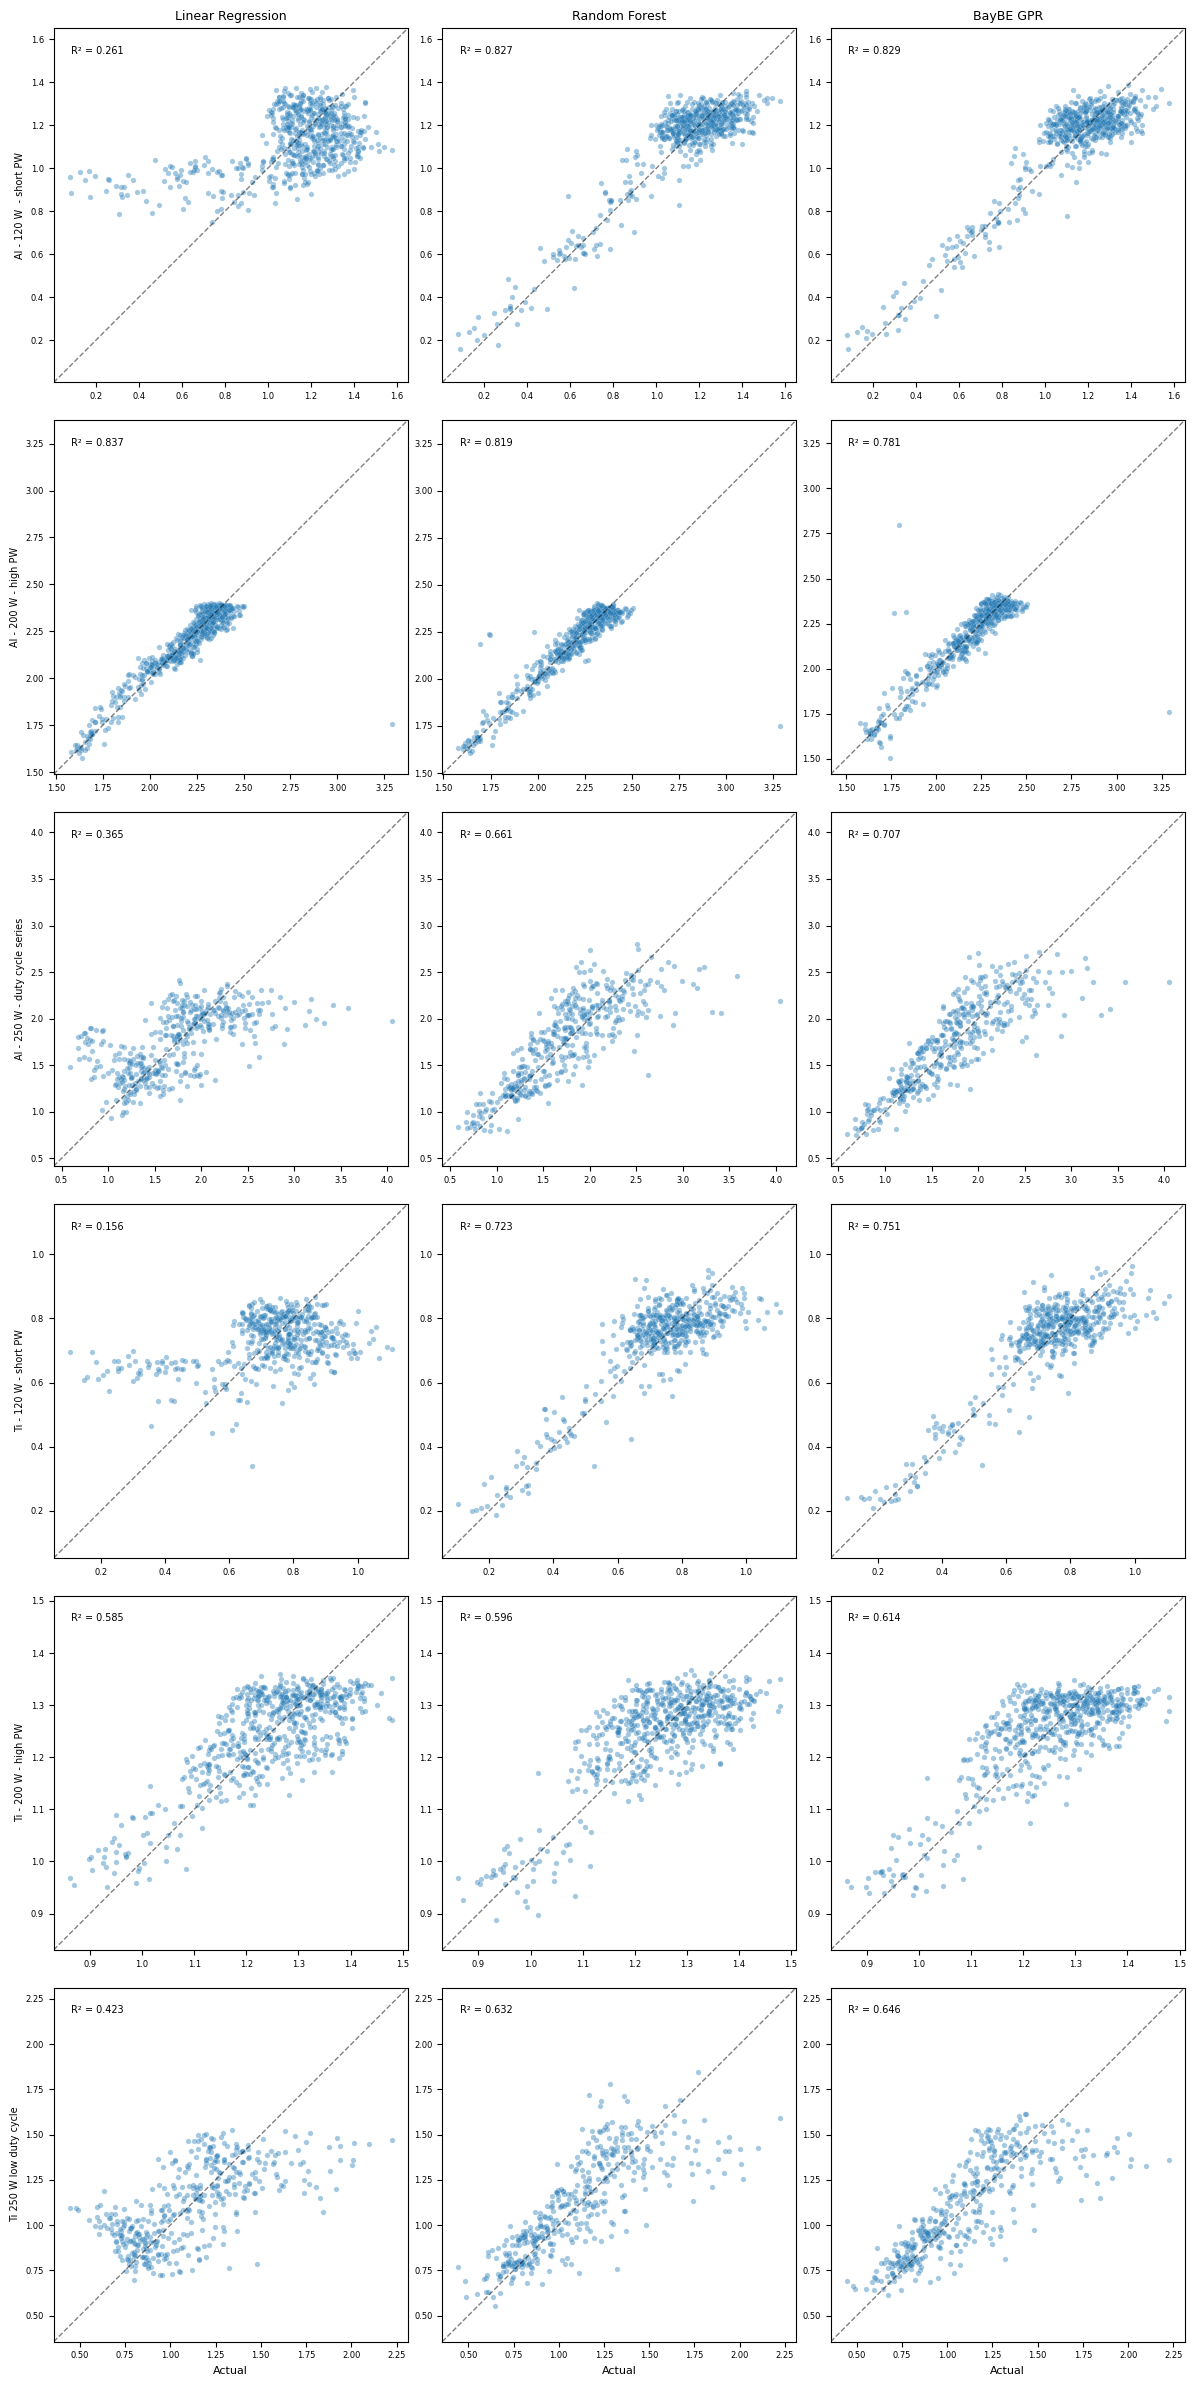

In [7]:
fig, axes = plt.subplots(len(ds_names), 3, figsize=(12, 4 * len(ds_names)))

for row, ds_name in enumerate(ds_names):
    for col, model_name in enumerate(model_names):
        ax = axes[row, col]
        result = all_results[ds_name][model_name]
        y_true = result['y_true_all']
        y_pred = result['y_pred_all']
        
        ax.scatter(y_true, y_pred, s=15, alpha=0.4, edgecolor='white', linewidth=0.2)
        
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        margin = (lims[1] - lims[0]) * 0.05
        ax.plot([lims[0]-margin, lims[1]+margin], [lims[0]-margin, lims[1]+margin],
                'k--', linewidth=1, alpha=0.5)
        ax.set_xlim(lims[0]-margin, lims[1]+margin)
        ax.set_ylim(lims[0]-margin, lims[1]+margin)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=6)
        
        r2 = r2_score(y_true, y_pred)
        ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=7, va='top')
        
        if row == 0:
            ax.set_title(model_name, fontsize=9)
        if col == 0:
            ax.set_ylabel(ds_name, fontsize=7)
        if row == len(ds_names) - 1:
            ax.set_xlabel('Actual', fontsize=8)

plt.tight_layout()
plt.show()

## Discussion

The GPR surrogate was not chosen through a model selection process — it is the surrogate model embedded in BayBE's Bayesian optimization framework. The GPR's posterior uncertainty (mean + variance) is what drives the active learning acquisition function to recommend the next experiment. Neither linear regression nor random forests provide calibrated posterior uncertainty in the same way, making them unsuitable as drop-in replacements for the exploration loop.

This comparison serves to verify that the data contains nonlinear structure that the GPR captures beyond what a simple linear model can explain. The random forest comparison further contextualizes the GPR's predictive performance against a flexible nonparametric baseline.